In [1]:
import pandas as pd
import numpy as np
from FaceQuant import FaceQuantVec
import os
from tqdm import tqdm

In [2]:
måske = [
    # 1A1
    'Airpuff2026-03-14T17_08_19_after5s_first1s', 
    'Airpuff2026-03-14T17_14_19_after5s_first1s', 
    'Airpuff2026-03-14T17_08_19_after5s_first1s',
    'Airpuff2026-03-14T17_14_19_after5s_first1s',
    'Airpuff2026-03-19T17_51_58_after5s_first1s',
    'Airpuff2026-03-19T17_51_58_after5s_first1s',
    'Airpuff2026-03-19T17_53_58_after5s_first1s',
    'Airpuff2026-03-19T17_55_58_after5s_first1s',
    'Airpuff2026-03-26T17_40_42_after5s_first1s',
    'Airpuff2026-04-02T18_58_42_after5s_first1s',
    'Sucrose2026-03-19T17_23_55_after5s_first1s',
    'Sucrose2026-03-19T17_27_55_after5s_first1s',
    'Sucrose2026-03-23T16_28_02_after5s_first1s',
    # 1A4
    'Airpuff2026-03-12T22_53_04_after5s_first1s',
    'Airpuff2026-03-23T16_06_31_after5s_first1s',
    'Airpuff2026-03-23T16_08_31_after5s_first1s',
    'Airpuff2026-03-23T16_06_31_after5s_first1s',
    'Airpuff2026-03-23T16_08_31_after5s_first1s',
    'Airpuff2026-03-30T15_57_47_after5s_first1s',
    # 1A11
    'Airpuff2026-03-14T17_53_44_after5s_first1s',
    'Airpuff2026-03-26T18_26_50_after5s_first1s',
    #4B1
    'Airpuff2026-03-14T13_52_19_after5s_first1s',
    'Airpuff2026-03-16T13_40_57_after5s_first1s',
    'Airpuff2026-03-16T13_46_57_after5s_first1s',
    'Airpuff2026-03-19T13_04_34_after5s_first1s',
    'Airpuff2026-03-19T13_10_35_after5s_first1s',
    #4B4
    'Airpuff2026-03-26T13_32_06_after5s_first1s',
    'Quinine2026-03-26T13_18_31_after5s_first2s',
    'Quinine2026-03-26T13_20_31_after5s_first2s',
    'Sucrose2026-04-03T08_37_23_after5s_first1s',
    #7C
    #10B3
    'Airpuff2026-03-12T18_30_59_after5s_first1s',
    'Quinine2026-04-02T12_02_24_after5s_first2s',
    'Sucrose2026-03-12T18_08_47_after5s_first1s',
    'Sucrose2026-03-19T11_39_02_after5s_first1s',
    #10B4
    'Airpuff2026-03-12T17_50_06_after5s_first1s',
    'Sucrose2026-03-23T10_33_45_after5s_first1s',

    ]

nope = [
    # 1A1
    'Airpuff2026-03-14T17_10_19_after5s_first1s', 
    'Airpuff2026-03-14T17_10_19_after5s_first1s',
    'Airpuff2026-03-19T17_55_58_after5s_first1s',
    # 1A4
    # 1A11
    'Airpuff2026-03-14T17_51_44_after5s_first1s',
    'Sucrose2026-03-16T17_30_33_after5s_first1s',
    'Sucrose2026-03-16T17_32_33_after5s_first1s',
    'Sucrose2026-03-16T17_34_33_after5s_first1s',
    'Sucrose2026-03-16T17_36_33_after5s_first1s',
    #4B1
    'Airpuff2026-03-14T13_54_19_after5s_first1s',
    'Sucrose2026-03-26T12_35_53_after5s_first1s',
    #4B4
    'Airpuff2026-03-14T14_33_17_after5s_first1s',
    'Airpuff2026-03-23T13_54_51_after5s_first1s',
    'Airpuff2026-03-26T13_34_06_after5s_first1s',
    #7C
    'Airpuff2026-03-12T22_02_28_after5s_first1s',
    'Airpuff2026-03-19T16_06_02_after5s_first1s',
    'Airpuff2026-03-30T14_12_20_after5s_first1s',
    #10B3
    'Airpuff2026-03-14T12_24_17_after5s_first1s',
    'Sucrose2026-03-14T11_52_36_after5s_first1s',
    #10B4
    'Airpuff2026-03-16T11_13_38_after5s_first1s',
    'Quinine2026-03-23T10_44_18_after5s_first2s',
    'Sucrose2026-03-30T10_42_12_after5s_first1s',
    ]

In [7]:
len('Airpuff2026-03-14T14_33_17_after5s_first1s')

42

## Load data

In [29]:
import os

csv_files = []

for root, dirs, files in os.walk('C2shortvideosDLCanalyzed_reanalyzed_v2/'):
    for f in files:
        if f.endswith('.csv') and f[:42] not in nope:
        #if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))



In [30]:
len(csv_files)

707

In [31]:
all_results = []

ill_dict = {
    '7C':'ill',
    '10B3':'ill',
    '1A1':'ill',
    '1A11':'ill',
    '10B4':'control',
    '1A4':'control',
    '4B1':'control',
    '4B4':'control',
    }

for csv_file in tqdm(csv_files):
    df = pd.read_csv(csv_file, header=[1, 2])
    df.columns.names = ["scorer", "bodyparts"]
    n = len(df)

    if n > 200:
        fq = FaceQuantVec(df)
        quant_df = fq.compute()

        quant_df["group"] = ill_dict[csv_file.split('\\')[1]]

        if '_' not in csv_file.split('\\')[2]:
            phase = 'pre'
        else:
            phase = csv_file.split('\\')[2].split('_')[1]

        quant_df["phase"] = phase 
        quant_df["file"] = csv_file 

        if "Airpuff" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["airpuf"] * (n - 200)
        elif "quinine" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["quinine"] * (n - 200)
        elif "Sucrose" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["sucrose"] * (n - 200)
    
        all_results.append(quant_df)

fq_df = pd.concat(all_results, ignore_index=True)


  0%|          | 0/707 [00:00<?, ?it/s]

100%|██████████| 707/707 [00:10<00:00, 69.36it/s]


In [43]:
fq_df

,eye_opening,ear_opening,ear_position,snout_position,mouth_position,face_inclination,group,phase,file,stimuli,PC1,PC2
0,-0.009383,-0.083569,0.131548,1.069210,-0.177854,-0.609260,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.127432,0.276238
1,-0.015710,-0.099878,0.332461,0.901795,-0.215155,-0.655484,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.234243,0.453904
2,-0.014771,-0.089998,0.323772,0.777328,-0.270970,-0.675655,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.322064,0.454220
3,-0.014363,-0.098557,0.391634,0.775335,-0.259698,-0.660421,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.306518,0.506959
4,-0.019870,-0.089731,0.419902,0.252176,-0.308094,-0.712036,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.534887,0.541318
...,...,...,...,...,...,...,...,...,...,...,...,...
266895,0.012015,0.038037,-0.015813,0.533746,-1.272054,-0.701984,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.041626,0.287303
266896,0.005116,0.058869,-0.022481,0.220570,-1.478967,-0.730123,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.287370,0.309111
266897,0.008768,0.060138,-0.004841,0.131913,-1.525592,-0.665565,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.303615,0.319268
266898,0.010045,0.065118,-0.063139,0.070386,-1.603348,-0.684557,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.379714,0.287757


In [44]:
fq_df_filter = fq_df[(fq_df['eye_opening'] < 1) & (fq_df['ear_opening'] < 1)]

In [45]:
from scipy.stats import zscore

quant_cols = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

fq_df_filter[quant_cols] = fq_df_filter[quant_cols].apply(zscore)
import numpy as np

mean_df = fq_df_filter.groupby("stimuli")[quant_cols].mean()
sem_df  = fq_df_filter.groupby("stimuli")[quant_cols].sem()



C:\Users\soren\AppData\Local\Temp\ipykernel_35416\553614504.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fq_df_filter[quant_cols] = fq_df_filter[quant_cols].apply(zscore)


In [61]:
c_group = []
for i, row in fq_df_filter.iterrows():
    if row['group'] == 'ill' and row['phase'] == 'pre':
        c_group.append('control')
    else:
        c_group.append(row['group'])

fq_df_filter['c_group'] = c_group

C:\Users\soren\AppData\Local\Temp\ipykernel_35416\4066119948.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fq_df_filter['c_group'] = c_group


In [60]:
fq_df_filter

,eye_opening,ear_opening,ear_position,snout_position,mouth_position,face_inclination,group,phase,file,stimuli,PC1,PC2,c_phase,c_group
0,-0.039196,-0.044075,0.122511,1.076938,-0.184992,-0.777275,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.582333,0.677488,control,control
1,-0.153877,-0.192822,0.347938,0.908699,-0.223221,-0.833318,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.724593,0.481101,control,control
2,-0.136864,-0.102712,0.338189,0.783618,-0.280424,-0.857773,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.789373,0.431647,control,control
3,-0.129463,-0.180775,0.414331,0.781615,-0.268871,-0.839304,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.773138,0.400085,control,control
4,-0.229279,-0.100280,0.446048,0.255879,-0.318471,-0.901881,ill,pre,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,-0.937817,0.086174,control,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266895,0.348656,1.065030,-0.042830,0.538836,-1.306404,-0.889695,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.291022,0.490186,W2,W2
266896,0.223613,1.255024,-0.050312,0.224118,-1.518462,-0.923811,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.523352,0.273770,W2,W2
266897,0.289792,1.266597,-0.030519,0.135024,-1.566247,-0.845540,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.481522,0.206007,W2,W2
266898,0.312942,1.312017,-0.095930,0.073194,-1.645937,-0.868566,ill,W2,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,-1.514097,0.155569,W2,W2


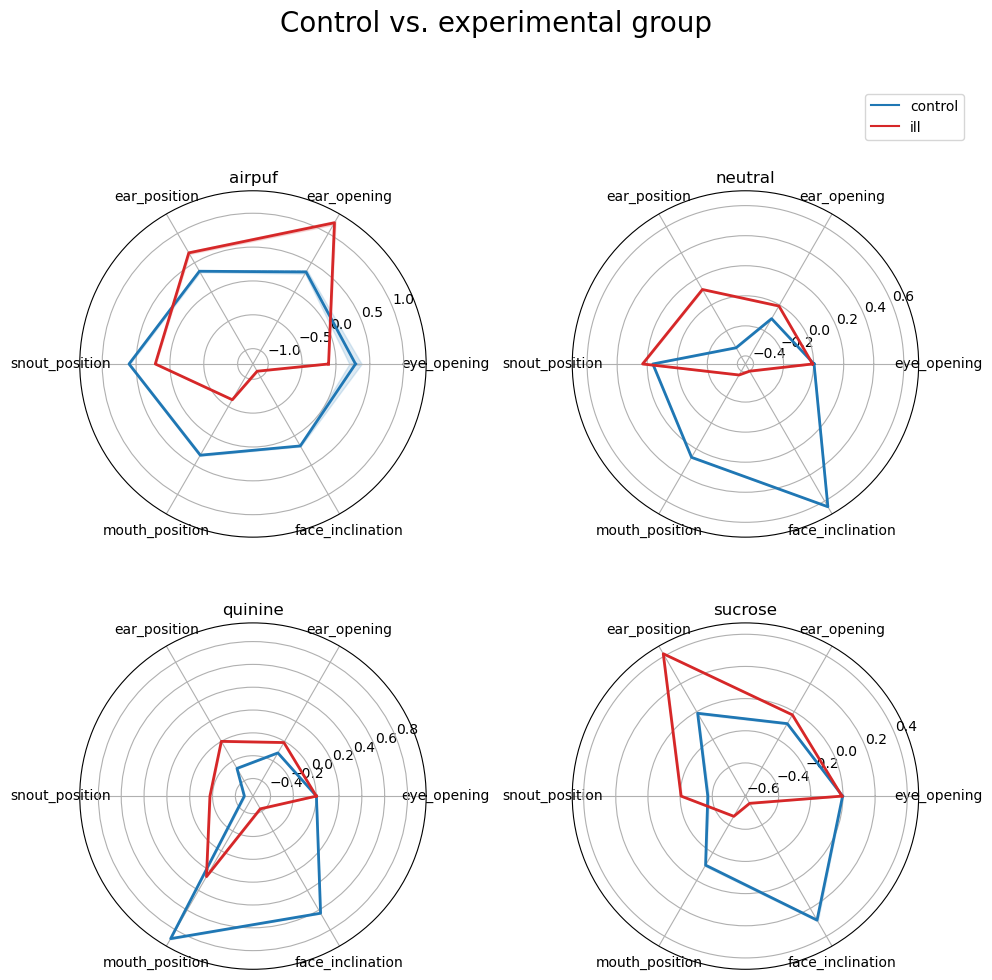

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["group"].unique())

# Explicit colors per group
group_colors = {
    "ill": "tab:red",
    "control": "tab:blue",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df[fq_df["stimuli"] == stim]

    stim_mean = stim_df.groupby("group")[quant_cols].mean()
    stim_sem  = stim_df.groupby("group")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

plt.suptitle("Control vs. experimental group", fontsize=20, y=1)
axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)

plt.tight_layout()
plt.savefig("cont_exp.svg")
plt.show()



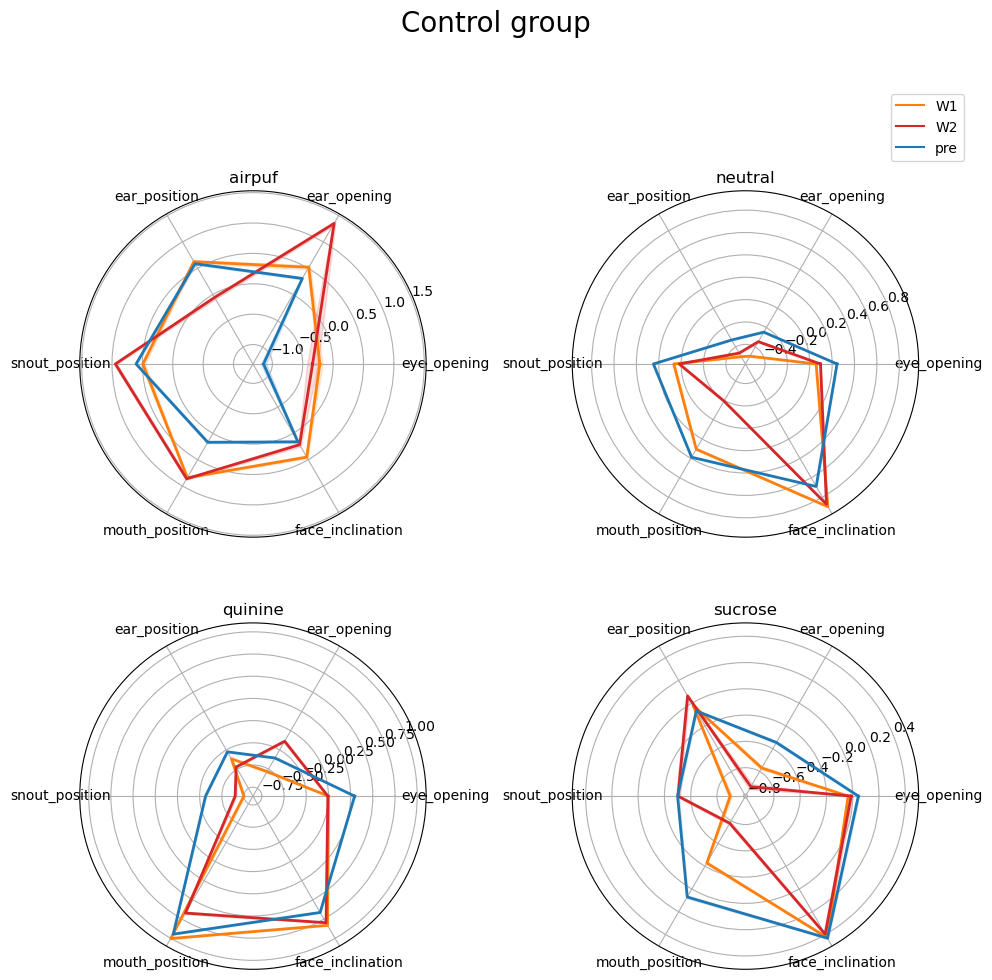

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df_filter["stimuli"].unique())
groups = sorted(fq_df_filter["phase"].unique())

# Explicit colors per group
group_colors = {
    "pre": "tab:blue",
    "W1": "tab:orange",
    "W2": "tab:red",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df_filter[(fq_df_filter["stimuli"] == stim) & (fq_df_filter["group"] == 'control')]

    stim_mean = stim_df.groupby("phase")[quant_cols].mean()
    stim_sem  = stim_df.groupby("phase")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

plt.suptitle("Control group", fontsize=20, y=1)
axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)

plt.tight_layout()
plt.savefig("cont_group.svg")
plt.show()

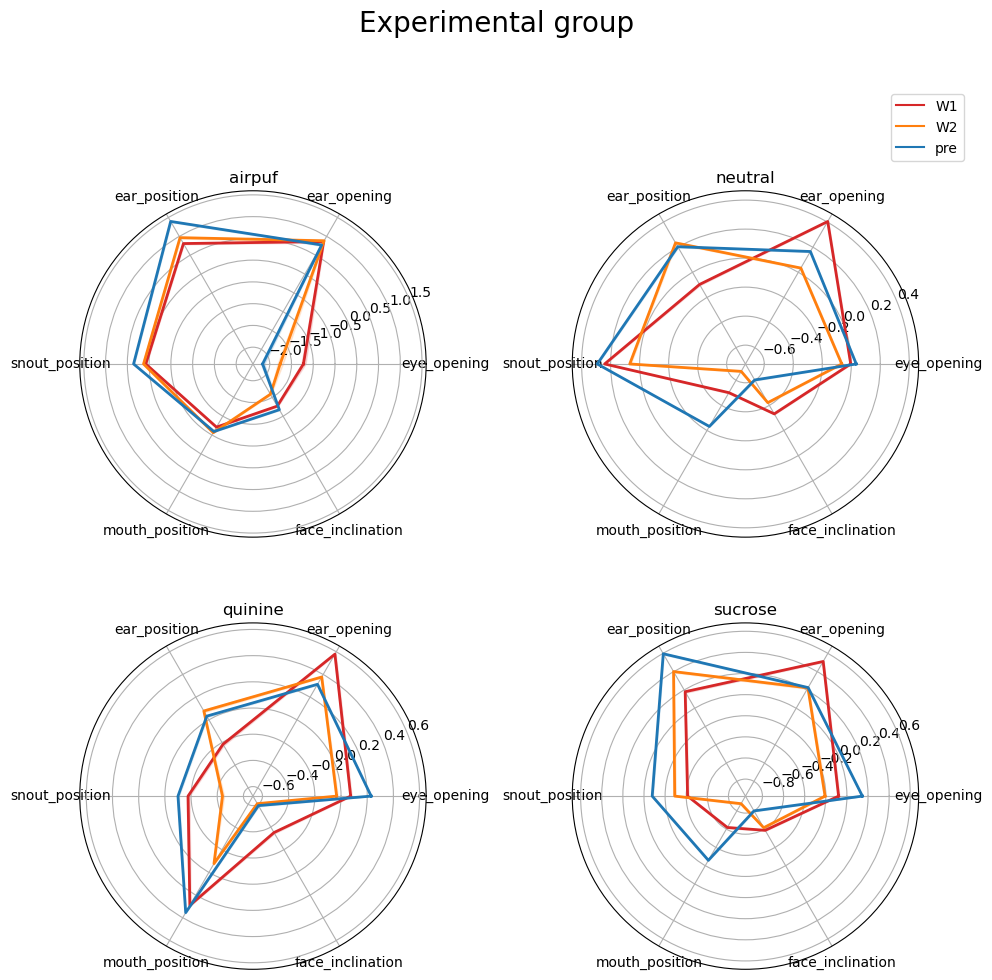

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df_filter["stimuli"].unique())
groups = sorted(fq_df_filter["phase"].unique())

# Explicit colors per group
group_colors = {
    "pre":"tab:blue",
    "W1": "tab:orange",
    "W2": "tab:red",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df_filter[(fq_df_filter["stimuli"] == stim) & (fq_df_filter["group"] == 'ill')]

    stim_mean = stim_df.groupby("phase")[quant_cols].mean()
    stim_sem  = stim_df.groupby("phase")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

plt.suptitle("Experimental group", fontsize=20, y=1)
axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)

plt.tight_layout()
plt.savefig("expg_group.svg")
plt.show()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:6.746e-102 t=-2.160e+01
neutral_ill vs. neutral_control: t-test independent samples, P_val:0.000e+00 t=-4.584e+01
quinine_ill vs. quinine_control: t-test independent samples, P_val:5.881e-06 t=-4.531e+00
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:6.819e-01 t=4.099e-01


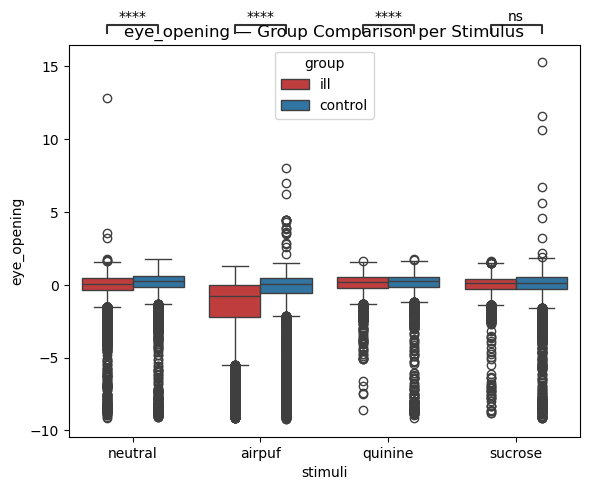

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:7.167e-41 t=1.343e+01
neutral_ill vs. neutral_control: t-test independent samples, P_val:0.000e+00 t=1.157e+02
quinine_ill vs. quinine_control: t-test independent samples, P_val:0.000e+00 t=9.673e+01
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:0.000e+00 t=8.725e+01


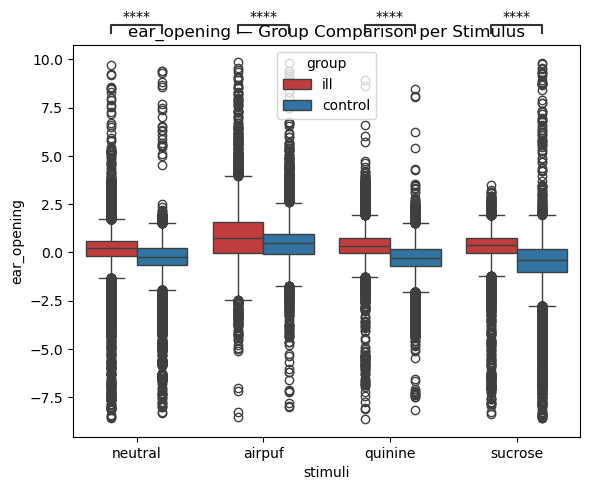

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:2.681e-232 t=3.315e+01
neutral_ill vs. neutral_control: t-test independent samples, P_val:0.000e+00 t=1.091e+02
quinine_ill vs. quinine_control: t-test independent samples, P_val:0.000e+00 t=4.385e+01
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:0.000e+00 t=5.440e+01


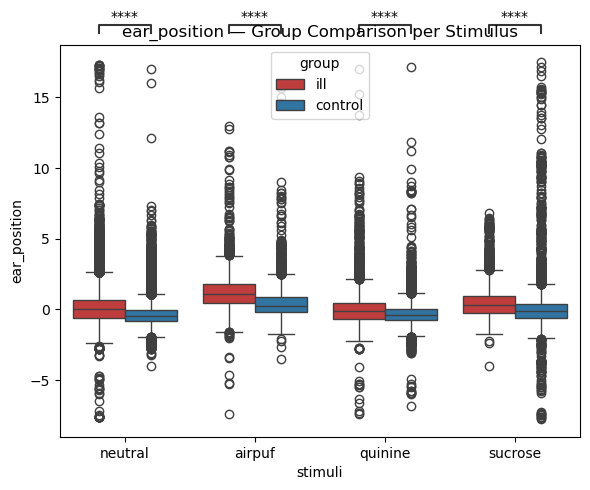

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:7.367e-127 t=-2.420e+01
neutral_ill vs. neutral_control: t-test independent samples, P_val:7.380e-48 t=1.454e+01
quinine_ill vs. quinine_control: t-test independent samples, P_val:8.396e-268 t=3.516e+01
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:8.890e-98 t=2.103e+01


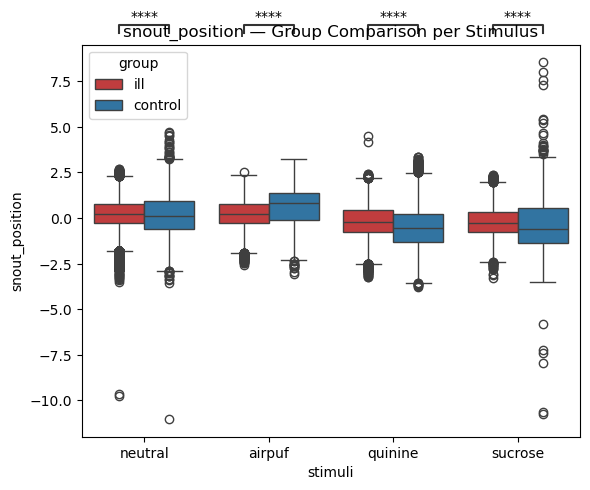

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:0.000e+00 t=-7.285e+01
neutral_ill vs. neutral_control: t-test independent samples, P_val:0.000e+00 t=-1.410e+02
quinine_ill vs. quinine_control: t-test independent samples, P_val:0.000e+00 t=-7.761e+01
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:0.000e+00 t=-4.355e+01


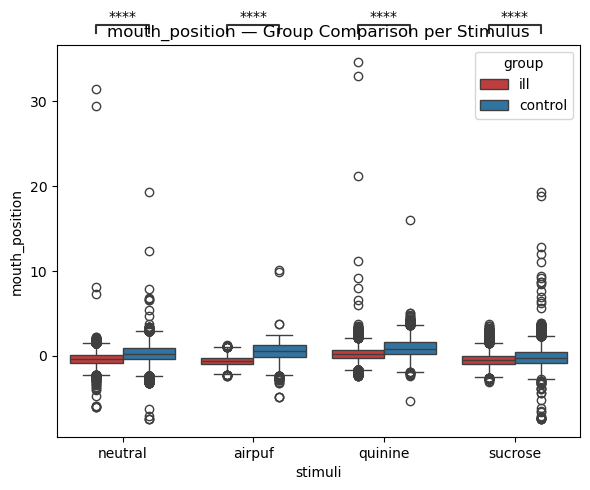

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airpuf_ill vs. airpuf_control: t-test independent samples, P_val:0.000e+00 t=-1.089e+02
neutral_ill vs. neutral_control: t-test independent samples, P_val:0.000e+00 t=-3.421e+02
quinine_ill vs. quinine_control: t-test independent samples, P_val:0.000e+00 t=-2.243e+02
sucrose_ill vs. sucrose_control: t-test independent samples, P_val:0.000e+00 t=-1.394e+02


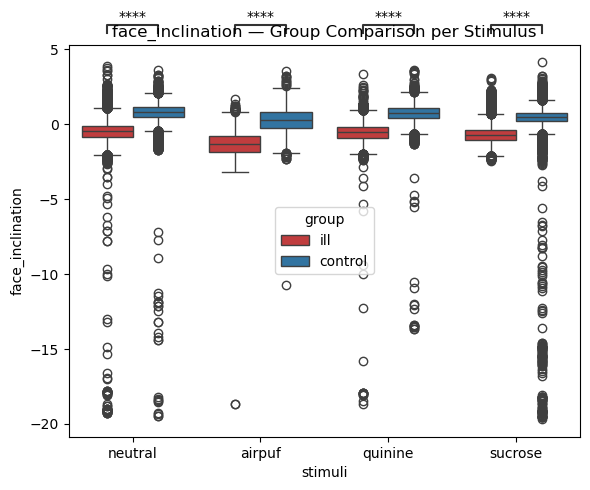

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fq_df_filter

for metric in quant_cols:
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(
        data=fq_df_filter,
        x="stimuli",
        y=metric,
        hue="group",
        palette={"ill": "tab:red", "control": "tab:blue"}
    )

    # Build only valid pairs
    valid_pairs = []
    for stim in fq_df_filter["stimuli"].unique():
        groups_present = fq_df_filter[fq_df_filter["stimuli"] == stim]["group"].unique()

        if "ill" in groups_present and "control" in groups_present:
            valid_pairs.append(
                ((stim, "ill"), (stim, "control"))
            )

    # Only annotate if at least one valid pair exists
    if valid_pairs:
        annot = Annotator(
            ax,
            valid_pairs,
            data=fq_df_filter,
            x="stimuli",
            y=metric,
            hue="group"
        )

        annot.configure(test="t-test_ind", text_format="star", loc="outside")
        annot.apply_and_annotate()

    plt.title(f"{metric} — Group Comparison per Stimulus")
    plt.tight_layout()
    plt.show()


C:\Users\soren\AppData\Local\Temp\ipykernel_35416\3582299213.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fq_df_filter["PC1"] = pcs[:, 0]
C:\Users\soren\AppData\Local\Temp\ipykernel_35416\3582299213.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fq_df_filter["PC2"] = pcs[:, 1]


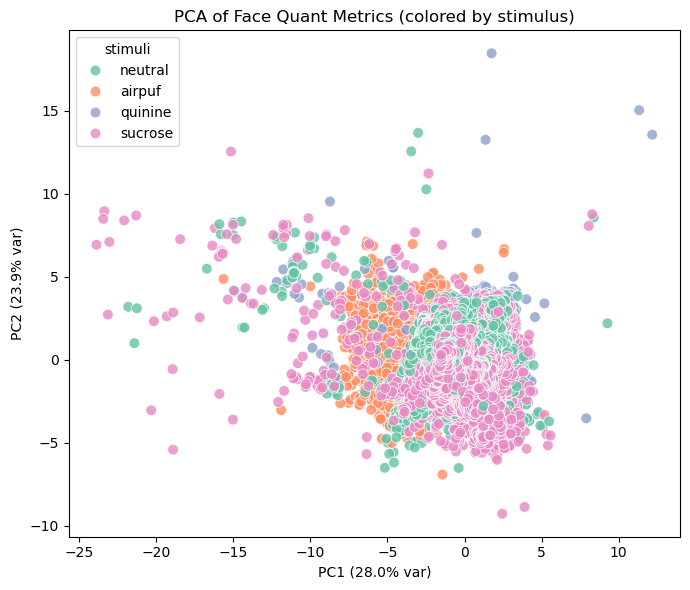

In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Extract only the quantitative columns
X = fq_df_filter[quant_cols].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Add PCA results back to dataframe
fq_df_filter["PC1"] = pcs[:, 0]
fq_df_filter["PC2"] = pcs[:, 1]

# Plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=fq_df_filter,
    x="PC1",
    y="PC2",
    hue="stimuli",
    palette="Set2",
    alpha=0.8,
    s=60
)

plt.title("PCA of Face Quant Metrics (colored by stimulus)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()
